In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, random_split, Subset
from datasets.binary_segment_dataset import BinarySegmentationDataset
from models.model_torch import train_model, save_checkpoint, load_checkpoint, UNet
from utils.util import plot_binary_segmentation
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

In [ ]:
device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu"
print(f"Using {device} device")

In [16]:
train_dataset = BinarySegmentationDataset(root='./data/semantic_drone_dataset')
batch_size = 32

generator = torch.Generator().manual_seed(42)
train_dataset, val_dataset = random_split(train_dataset, [.8,.2], generator=generator)
first_1000_train_ds = Subset(train_dataset, range(1000))

train_dataloader = DataLoader(first_1000_train_ds, batch_size=batch_size, shuffle=True)
val_dataloader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
# test_dataloader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(len(first_1000_train_ds), len(val_dataset))

1000 80


### Explore this dataset

begin Mask([[[0, 0, 0,  ..., 0, 0, 0],
       [0, 0, 0,  ..., 0, 0, 0],
       [0, 0, 0,  ..., 1, 1, 0],
       ...,
       [0, 0, 0,  ..., 1, 1, 0],
       [0, 0, 0,  ..., 1, 1, 0],
       [0, 0, 0,  ..., 1, 1, 0]]], dtype=torch.uint8)
shape torch.Size([3, 4000, 6000])
mask after transform Mask([[[ 0, 10, 10,  ...,  0,  0,  0],
       [ 0, 10, 10,  ..., 22, 22, 22],
       [ 0, 10, 10,  ..., 22, 22, 22],
       ...,
       [ 0,  1,  1,  ...,  8,  8,  8],
       [ 0,  1,  1,  ...,  8,  8,  8],
       [ 0,  1,  1,  ...,  8,  8,  8]]], dtype=torch.uint8)
mask result tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.]]])
513.jpg 513.png
origin [[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 1 1 0]
 ...
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]
 [0 0 0 ... 1 1 0]]
<class 'torchvision.tv_t

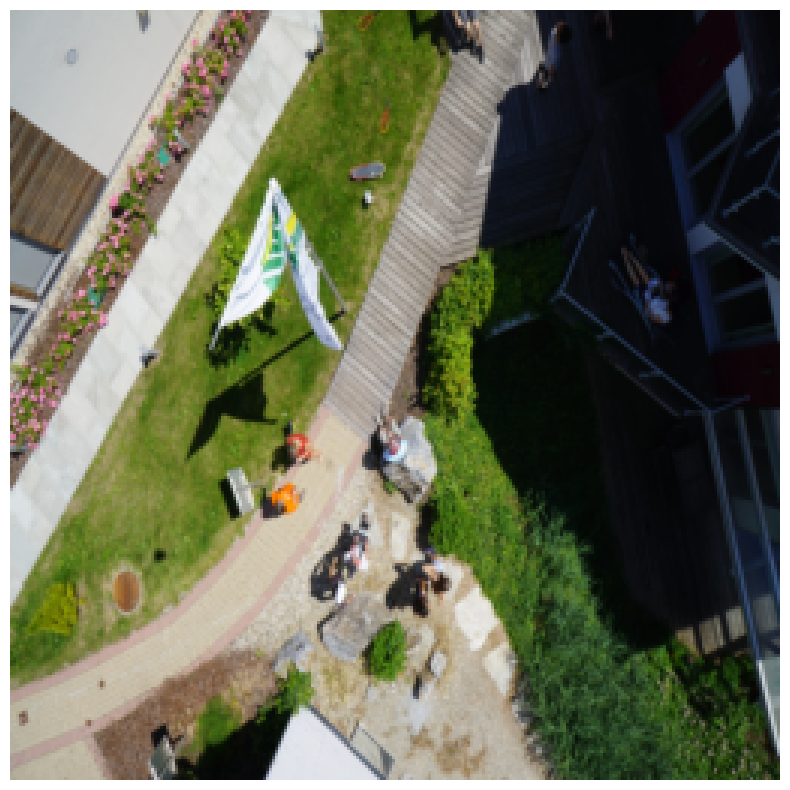

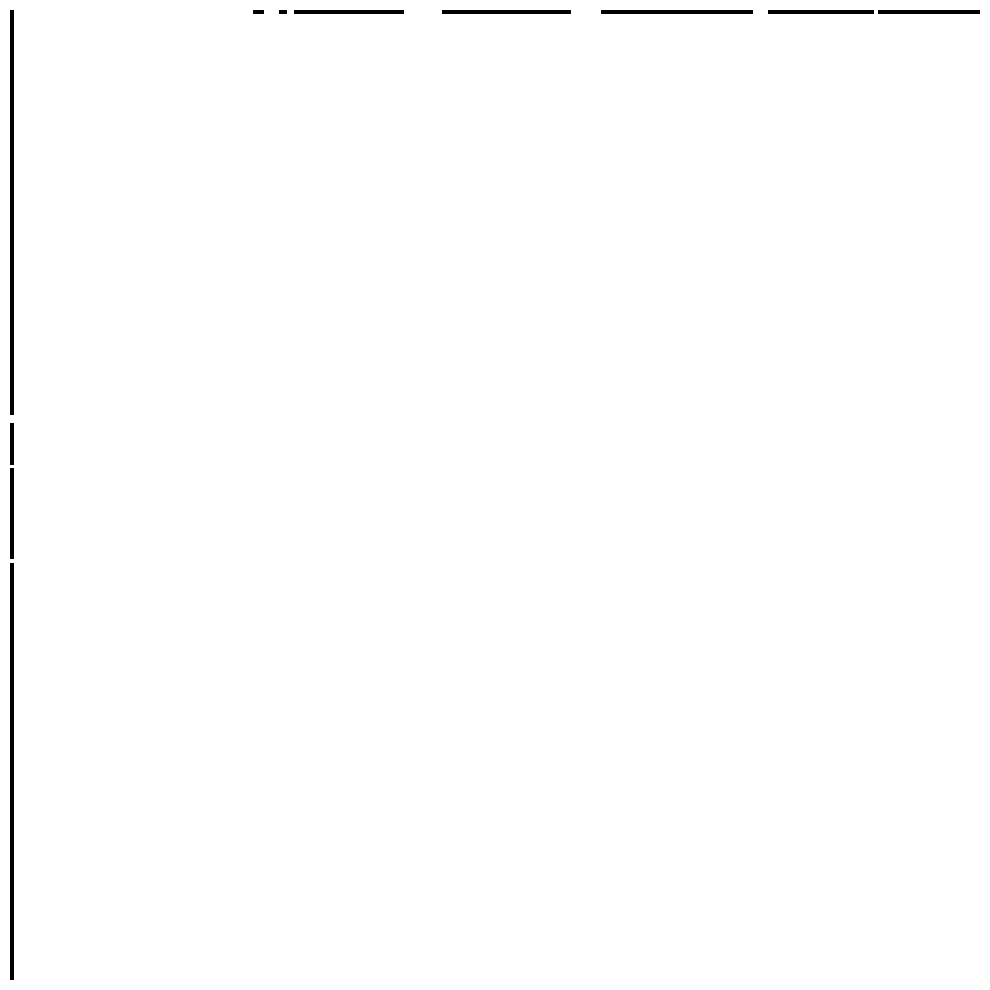

tensor([[[0., 1., 1.,  ..., 0., 0., 0.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         ...,
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.],
         [0., 1., 1.,  ..., 1., 1., 1.]]])


In [18]:
image, mask = train_dataset[0]
original_idx = train_dataset.indices[0]
image_path = train_dataset.dataset.images[original_idx] 
mask_path = train_dataset.dataset.masks[original_idx] 
print(image_path, mask_path)

mask1 = Image.open('./data/semantic_drone_dataset/label_images_semantic/'+mask_path).convert('L')
print("origin",np.asarray(mask1))
# plt.imshow(mask1)
# plt.show()

print(type(image), type(mask), image.shape, mask.shape)
# breed_name = train_dataset.dataset.classes[target]
# print(breed_name)
plot_binary_segmentation(image,mask)
print(mask)